In [ ]:
from google.colab import files
uploaded = files.upload()

Saving livestock_feed_data.xlsx to livestock_feed_data.xlsx


**DECISION TREE **

Sample Dataset:/n      Weight  Age  Milk_Yield  Activity_Level  Temperature  Humidity  \
995     569   36        14.8               7           37        71   
996     309   41        19.8               4           27        81   
997     569   25        15.5               6           35        54   
998     598   18         5.7               7           26        72   
999     577   28        22.4               6           34        54   

     Feed_Intake        Feed_Category  
995        17.71  Provide lesser feed  
996        11.32      Feed is optimum  
997        18.00      Feed is optimum  
998        16.53  Provide lesser feed  
999        19.10      Feed is optimum  

=== Decision Tree - Regression ===
MAE : 0.168 kg/day

=== Enter Details for Prediction ===
Enter Weight (kg): 400
Enter Age(months): 20
Enter Milk Yield(L/day): 10
Enter Activity Level(1-10): 8
Enter Temperature(°C): 25
Enter Humidity(%): 90
Enter Feed Intake(kg/day): 10

=== Prediction Result ===
Feed amount  :

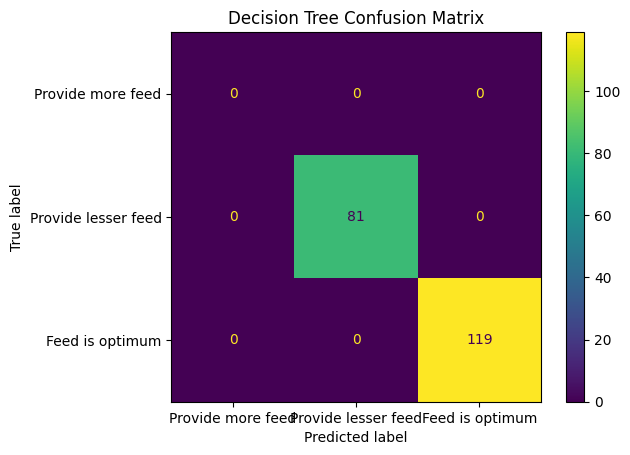

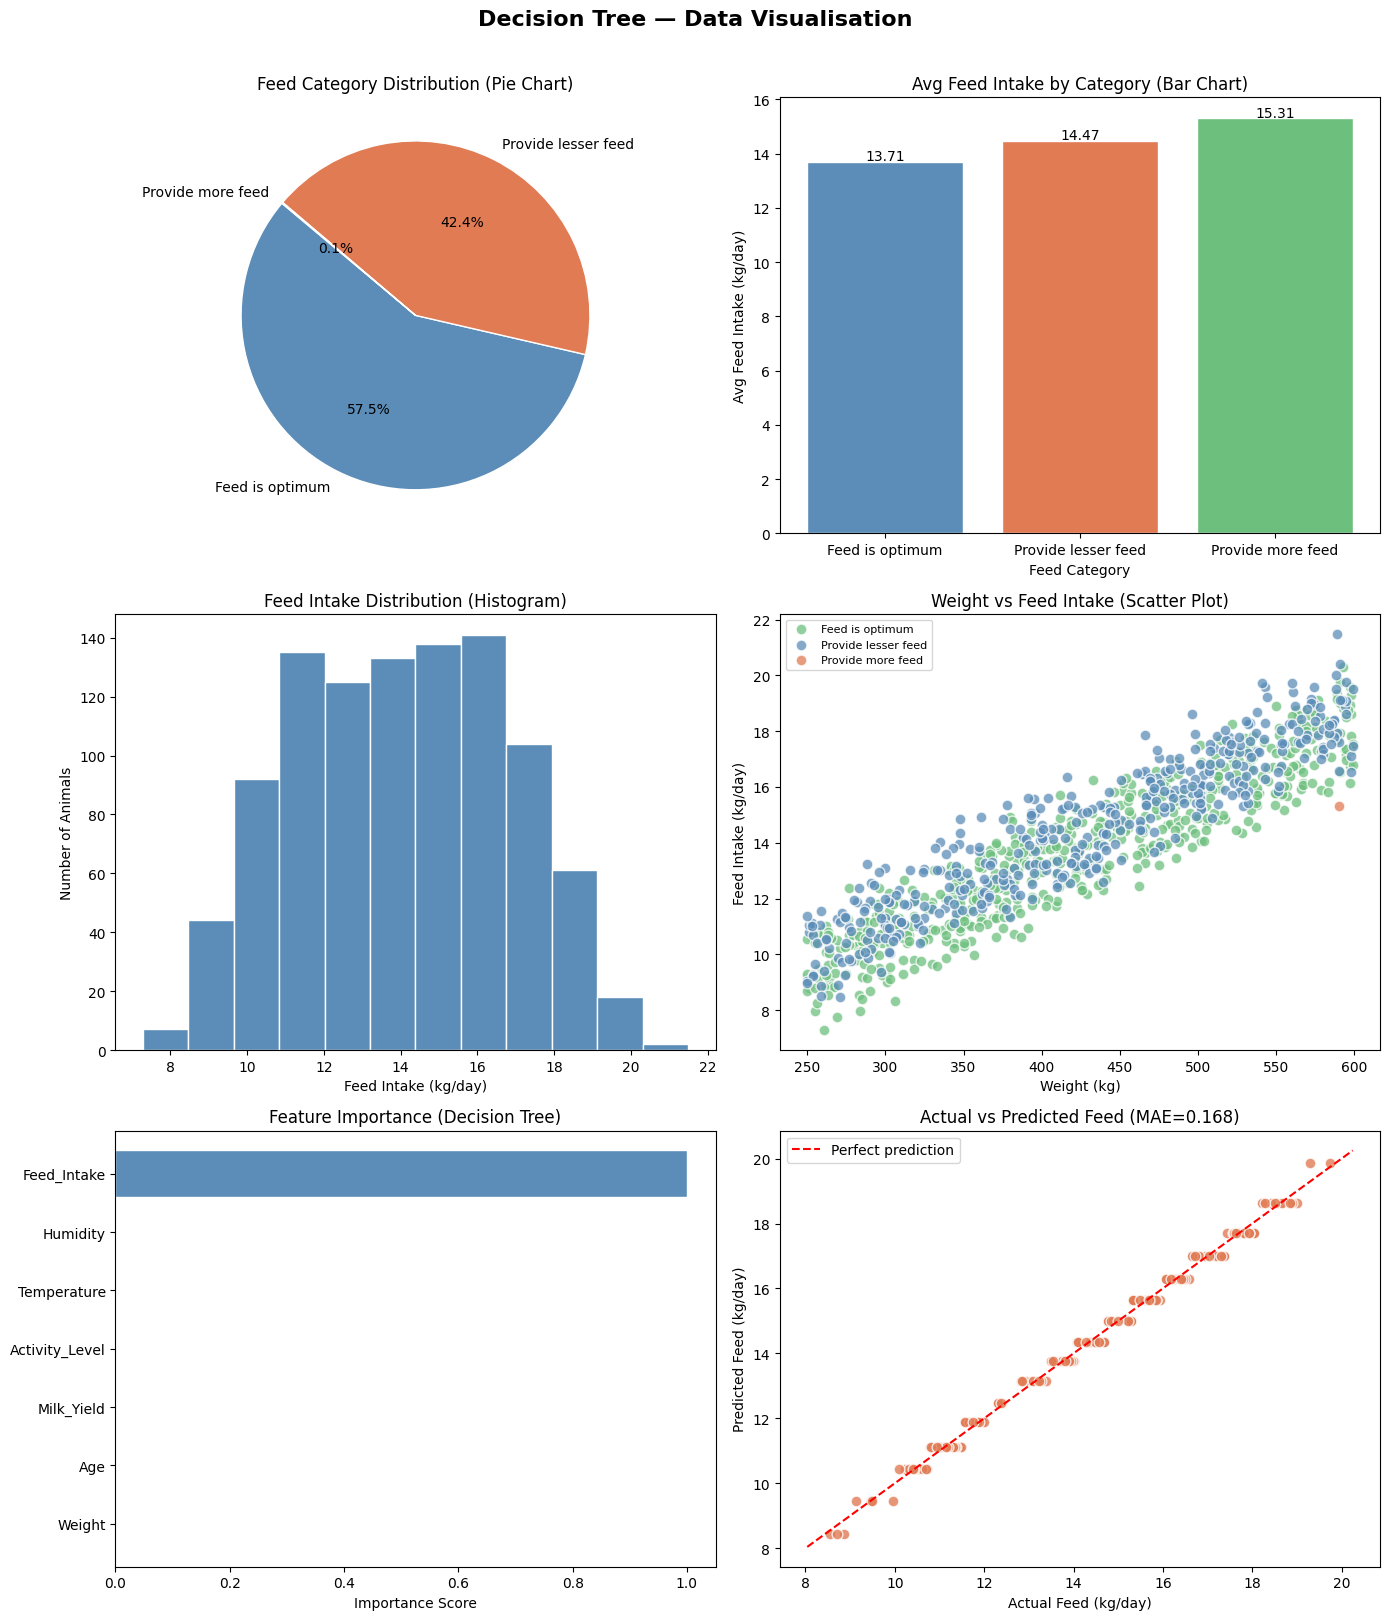


 Graphs saved: decision_tree_graphs.png


In [ ]:
# ====================================================================
# Step 1: Import Libraries
# ====================================================================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# =====================================================================
# Step 2: Load Dataset
# =====================================================================

df = pd.read_excel("livestock_feed_data.xlsx")

# =====================================================================
# Step 3: Create Feed Category
# =====================================================================
def classify_feed(row):
    feed = row["Weight"] * 0.0265
    if row["Feed_Intake"] < feed and row["Activity_Level"] <= 5:
        return "Provide more feed"
    elif row["Feed_Intake"] >feed and row["Activity_Level"] > 6:
        return "Provide lesser feed"
    else:
        return "Feed is optimum"

df["Feed_Category"] = df.apply(classify_feed, axis=1)
print("Sample Dataset:/n",df.tail())

# =======================================================================
# Step 4: Features & Targets
# =======================================================================
X = df[["Weight", "Age", "Milk_Yield", "Activity_Level", "Temperature", "Humidity","Feed_Intake"]]
y_clf = df["Feed_Category"]

# ========================================================================
# Step 5: Train-Test-Split
# ========================================================================
X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

# =======================================================================
# Step 6: Decision Tree - Regression (Added)
# =======================================================================
dt_reg = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_reg.fit(X_train, yr_train)
yr_pred = dt_reg.predict(X_test)

print("\n=== Decision Tree - Regression ===")
print(f"MAE : {mean_absolute_error(yr_test, yr_pred):.3f} kg/day")

# =======================================================================
# Step 7: Decision Tree - Classification
# =======================================================================
dt_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_clf.fit(X_train, yc_train)
yc_pred = dt_clf.predict(X_test)

# =======================================================================
# Step 8: Prediction for New Animal
# =======================================================================
print("\n=== Enter Details for Prediction ===")

weight = float(input("Enter Weight (kg): "))
age = float(input("Enter Age(months): "))
milk_yield = float(input("Enter Milk Yield(L/day): "))
activity_level = float(input("Enter Activity Level(1-10): "))
temperature = float(input("Enter Temperature(°C): "))
humidity = float(input("Enter Humidity(%): "))
feed_intake=float(input("Enter Feed Intake(kg/day): "))

# =======================================================================
# Step 9: Create DataFrame from user input
# =======================================================================

new_animal = pd.DataFrame([[weight, age, milk_yield, activity_level, temperature, humidity,feed_intake]],
                          columns=["Weight", "Age", "Milk_Yield", "Activity_Level", "Temperature", "Humidity","Feed_Intake"])

print("\n=== Prediction Result ===")
print(f"Feed amount  : {dt_reg.predict(new_animal)[0]:.2f} kg/day")

# =======================================================================
# Step 10: Classification Prediction
# =======================================================================

feed_category = dt_clf.predict(new_animal)[0]
print(f"Feed category: {feed_category}")

# =======================================================================
# Step 11: Confusion matrix
# =======================================================================

cm_dt=confusion_matrix(yc_test,yc_pred,labels=["Provide more feed","Provide lesser feed","Feed is optimum"])
print("\n Decision Tree Confusion matrix: /n /n ", cm_dt)

# =======================================================================
# Step 12: Visual Confusion matrix
# =======================================================================

ConfusionMatrixDisplay.from_predictions(yc_test,yc_pred,labels=["Provide more feed","Provide lesser feed","Feed is optimum"])
plt.title("Decision Tree Confusion Matrix")
plt.show()

# =======================================================================
#                             VISUALIZATIONS
# =======================================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle("Decision Tree — Data Visualisation", fontsize=16, fontweight="bold", y=1.01)
colors = ["#5B8DB8", "#E07B54", "#6DBF7E"]

# ========================================================================
# Graph 1: Pie Chart — Feed Category Distribution
# ========================================================================

cat_counts = df["Feed_Category"].value_counts()
axes[0, 0].pie(cat_counts, labels=cat_counts.index, autopct="%1.1f%%",
               colors=colors, startangle=140, wedgeprops={"edgecolor": "white"})
axes[0, 0].set_title("Feed Category Distribution (Pie Chart)")
# ========================================================================
# Graph 2: Bar Chart — Average Feed Intake by Category
# ========================================================================

avg_feed = df.groupby("Feed_Category")["Feed_Intake"].mean()
# Ensuring `colors` list has enough elements or adjusting `avg_feed.index` if fewer unique categories
bar_colors = [colors[i % len(colors)] for i in range(len(avg_feed.index))]
axes[0, 1].bar(avg_feed.index, avg_feed.values, color=bar_colors, edgecolor="white")
axes[0, 1].set_title("Avg Feed Intake by Category (Bar Chart)")
axes[0, 1].set_xlabel("Feed Category")
axes[0, 1].set_ylabel("Avg Feed Intake (kg/day)")
for i, v in enumerate(avg_feed.values):
    axes[0, 1].text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=10)

# =======================================================================
#  Graph 3: Histogram — Feed Intake Distribution
# =======================================================================

axes[1, 0].hist(df["Feed_Intake"], bins=12, color="#5B8DB8", edgecolor="white")
axes[1, 0].set_title("Feed Intake Distribution (Histogram)")
axes[1, 0].set_xlabel("Feed Intake (kg/day)")
axes[1, 0].set_ylabel("Number of Animals")

# =======================================================================
#  Graph 4: Scatter Plot — Weight vs Feed Intake
# =======================================================================

scatter_colors = {"Provide more feed": "#E07B54",
                  "Provide lesser feed": "#5B8DB8",
                  "Feed is optimum": "#6DBF7E"}
for cat, grp in df.groupby("Feed_Category"):
    axes[1, 1].scatter(grp["Weight"], grp["Feed_Intake"],
                       label=cat, color=scatter_colors[cat], alpha=0.75, edgecolors="white", s=60)
axes[1, 1].set_title("Weight vs Feed Intake (Scatter Plot)")
axes[1, 1].set_xlabel("Weight (kg)")
axes[1, 1].set_ylabel("Feed Intake (kg/day)")
axes[1, 1].legend(fontsize=8)

# =======================================================================
#  Graph 5: Feature Importance — Bar Chart
# =======================================================================

feat_imp = pd.Series(dt_reg.feature_importances_, index=X.columns).sort_values()
axes[2, 0].barh(feat_imp.index, feat_imp.values, color="#5B8DB8", edgecolor="white")
axes[2, 0].set_title("Feature Importance (Decision Tree)")
axes[2, 0].set_xlabel("Importance Score")

# ========================================================================
# Graph 6: Actual vs Predicted — Scatter
# ========================================================================

axes[2, 1].scatter(yr_test, yr_pred, color="#E07B54", alpha=0.8, edgecolors="white", s=60)
lims = [yr_test.min() - 0.5, yr_test.max() + 0.5]
axes[2, 1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[2, 1].set_title(f"Actual vs Predicted Feed (MAE={mean_absolute_error(yr_test, yr_pred):.3f})")
axes[2, 1].set_xlabel("Actual Feed (kg/day)")
axes[2, 1].set_ylabel("Predicted Feed (kg/day)")
axes[2, 1].legend()

plt.tight_layout()
plt.savefig("decision_tree_graphs.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n Graphs saved: decision_tree_graphs.png")

In [ ]:
# Feature importance
importance=pd.DataFrame(dt_clf.feature_importances_,index=X_train.columns,columns=["Importance"])
print("/nFeature Importance:\n",importance)

/nFeature Importance:
                 Importance
Weight            0.000307
Age               0.000000
Milk_Yield        0.000000
Activity_Level    0.994922
Temperature       0.000000
Humidity          0.004771
Feed_Intake       0.000000


**RANDOM FOREST**

Sample Dataset:/n      Weight  Age  Milk_Yield  Activity_Level  Temperature  Humidity  \
995     569   36        14.8               7           37        71   
996     309   41        19.8               4           27        81   
997     569   25        15.5               6           35        54   
998     598   18         5.7               7           26        72   
999     577   28        22.4               6           34        54   

     Feed_Intake        Feed_Category  
995        17.71  Provide lesser feed  
996        11.32      Feed is optimum  
997        18.00      Feed is optimum  
998        16.53  Provide lesser feed  
999        19.10      Feed is optimum  
=== Random Forest - Regression ===
MAE : 0.010 kg/day

=== Enter Details for Prediction ===
Enter Weight (kg): 400
Enter Age(months): 30
Enter Milk Yield(l): 10
Enter Activity Level(1-10): 8
Enter Temperature(Celsius): 25
Enter Humidity(%): 90
Enter Feed Intake(kg/day): 10

=== Prediction Result ===
Feed amount  :

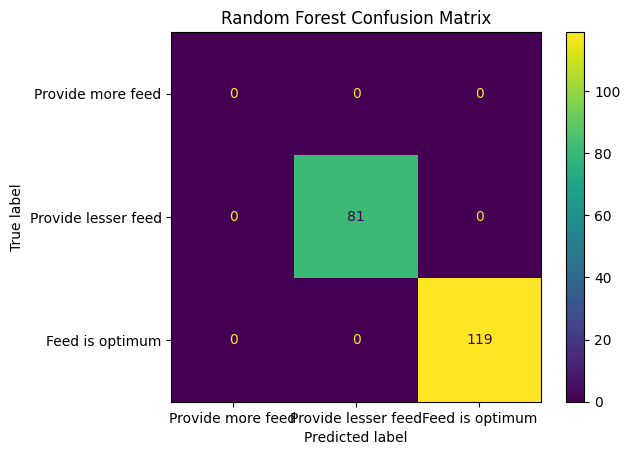

/tmp/ipykernel_6976/2293916309.py:143: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(box_data, patch_artist=True, labels=categories)


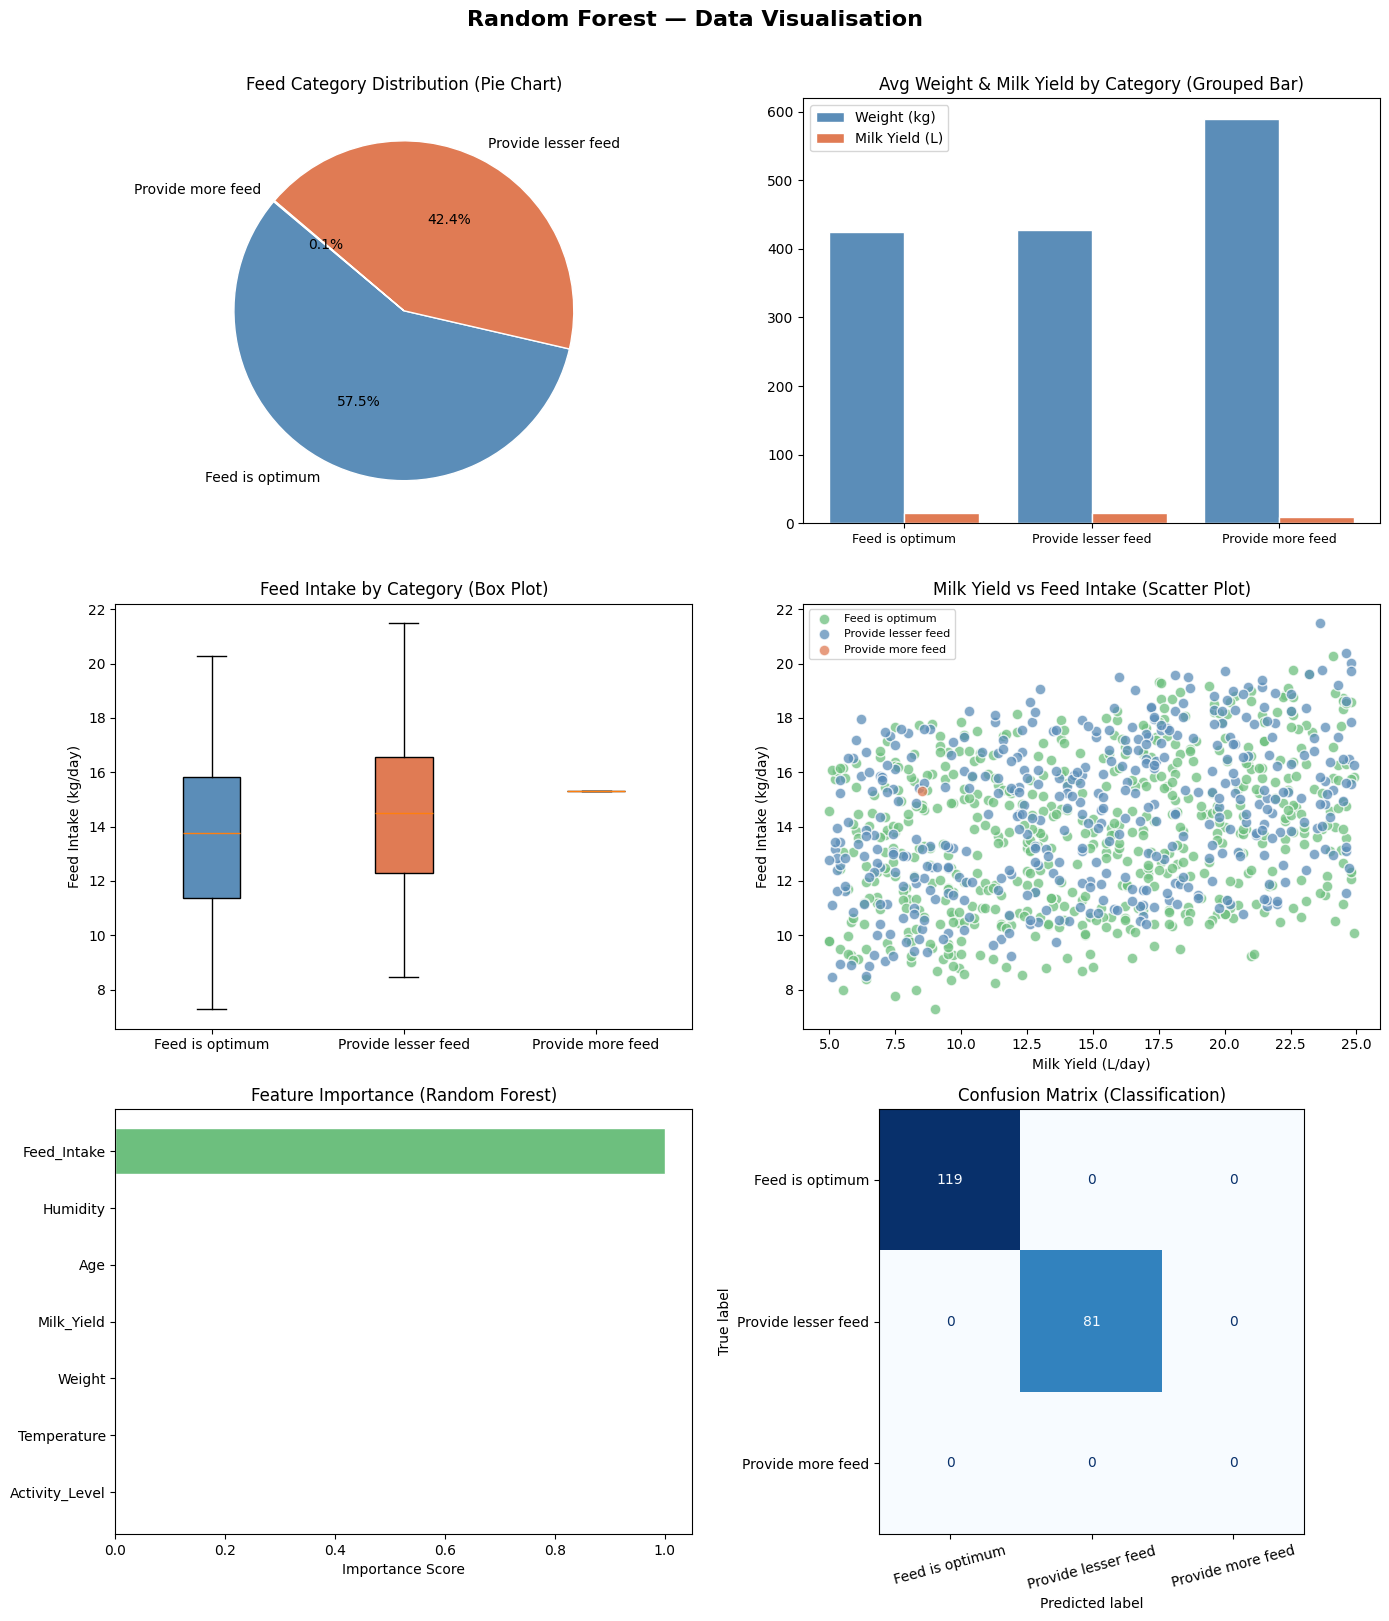


Graphs saved: random_forest_graphs.png


In [ ]:
# ==================================================================
# Step 1: Import Libraries
# ==================================================================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ====================================================================
#  Step 2: Load Dataset
# ====================================================================
df = pd.read_excel("livestock_feed_data.xlsx")

 # ===================================================================
#  Step 3: Create feed Category
# ====================================================================
def classify_feed(row):
    feed = row["Weight"] * 0.0265

    if row["Feed_Intake"] < feed and row["Activity_Level"] < 5:
        return "Provide more feed"
    elif row["Feed_Intake"] >= feed and row["Activity_Level"] > 6:
        return "Provide lesser feed"
    else:
        return "Feed is optimum"

df["Feed_Category"] = df.apply(classify_feed, axis=1)
print("Sample Dataset:/n",df.tail())

# =====================================================================
#  Step 4: Features & Targets
# =====================================================================
X = df[["Weight", "Age", "Milk_Yield", "Activity_Level", "Temperature", "Humidity","Feed_Intake"]]
y_clf = df["Feed_Category"]

# =====================================================================
#  Step 5: Train-Test-Split
# =====================================================================
X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

# ====================================================================
#  Step 6: Random Forest - Regression
# ====================================================================
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, yr_train)
yr_pred = rf_reg.predict(X_test)

print("=== Random Forest - Regression ===")
print(f"MAE : {mean_absolute_error(yr_test, yr_pred):.3f} kg/day")

# ====================================================================
#  Step 7: Random Forest - Classification
# ====================================================================
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, yc_train)
yc_pred = rf_clf.predict(X_test)

# =====================================================================
#  Step 8: Prediction for a New Animal
# =====================================================================
print("\n=== Enter Details for Prediction ===")

weight = float(input("Enter Weight (kg): "))
age = float(input("Enter Age(months): "))
milk_yield = float(input("Enter Milk Yield(l): "))
activity_level = float(input("Enter Activity Level(1-10): "))
temperature = float(input("Enter Temperature(Celsius): "))
humidity = float(input("Enter Humidity(%): "))
feed_intake=float(input("Enter Feed Intake(kg/day): "))

# =======================================================================
# Step 9: Create DataFrame from user input
# =======================================================================

new_animal = pd.DataFrame([[weight, age, milk_yield, activity_level, temperature, humidity,feed_intake]],
                          columns=["Weight", "Age", "Milk_Yield", "Activity_Level", "Temperature", "Humidity","Feed_Intake"])

print("\n=== Prediction Result ===")
print(f"Feed amount  : {dt_reg.predict(new_animal)[0]:.2f} kg/day")

# =======================================================================
# Step 10: Classification Prediction
# =======================================================================

feed_category = dt_clf.predict(new_animal)[0]
print(f"Feed category: {feed_category}")

# =======================================================================
# Step 11: Confusion matrix
# =======================================================================

cm_dt=confusion_matrix(yc_test,yc_pred,labels=["Provide more feed","Provide lesser feed","Feed is optimum"])
print("\n Random Forest Confusion matrix: /n /n ", cm_dt)

# =======================================================================
# Step 12: Visual Confusion matrix
# =======================================================================

ConfusionMatrixDisplay.from_predictions(yc_test,yc_pred,labels=["Provide more feed","Provide lesser feed","Feed is optimum"])
plt.title("Random Forest Confusion Matrix")
plt.show()

## =====================================================================
#                                  VISUALIZATIONS
# ======================================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle("Random Forest — Data Visualisation", fontsize=16, fontweight="bold", y=1.01)
colors = ["#5B8DB8", "#E07B54", "#6DBF7E"]

# ======================================================================
# Graph 1: Pie Chart — Feed Category Distribution
# ======================================================================

cat_counts = df["Feed_Category"].value_counts()
axes[0, 0].pie(cat_counts, labels=cat_counts.index, autopct="%1.1f%%",
               colors=colors, startangle=140, wedgeprops={"edgecolor": "white"})
axes[0, 0].set_title("Feed Category Distribution (Pie Chart)")

# ======================================================================
# Graph 2: Grouped Bar Chart — Avg Weight & Milk Yield by Category
# ======================================================================

avg_stats = df.groupby("Feed_Category")[["Weight", "Milk_Yield"]].mean()
x = range(len(avg_stats))
axes[0, 1].bar([i - 0.2 for i in x], avg_stats["Weight"], width=0.4,
               label="Weight (kg)", color="#5B8DB8", edgecolor="white")
axes[0, 1].bar([i + 0.2 for i in x], avg_stats["Milk_Yield"], width=0.4,
               label="Milk Yield (L)", color="#E07B54", edgecolor="white")
axes[0, 1].set_xticks(list(x))
axes[0, 1].set_xticklabels(avg_stats.index, fontsize=9)
axes[0, 1].set_title("Avg Weight & Milk Yield by Category (Grouped Bar)")
axes[0, 1].legend()

# ======================================================================
# Graph 3: Box Plot — Feed Intake by Category
# ======================================================================

categories = df["Feed_Category"].unique()
box_data = [df[df["Feed_Category"] == c]["Feed_Intake"].values for c in categories]
bp = axes[1, 0].boxplot(box_data, patch_artist=True, labels=categories)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
axes[1, 0].set_title("Feed Intake by Category (Box Plot)")
axes[1, 0].set_ylabel("Feed Intake (kg/day)")

# =======================================================================
# Graph 4: Scatter Plot — Milk Yield vs Feed Intake
# =======================================================================

scatter_colors = {"Provide more feed": "#E07B54",
                  "Provide lesser feed": "#5B8DB8",
                  "Feed is optimum": "#6DBF7E"}
for cat, grp in df.groupby("Feed_Category"):
    axes[1, 1].scatter(grp["Milk_Yield"], grp["Feed_Intake"],
                       label=cat, color=scatter_colors[cat], alpha=0.75, edgecolors="white", s=60)
axes[1, 1].set_title("Milk Yield vs Feed Intake (Scatter Plot)")
axes[1, 1].set_xlabel("Milk Yield (L/day)")
axes[1, 1].set_ylabel("Feed Intake (kg/day)")
axes[1, 1].legend(fontsize=8)
# ======================================================================
# Graph 5: Feature Importance — Horizontal Bar
# ======================================================================

feat_imp = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values()
axes[2, 0].barh(feat_imp.index, feat_imp.values, color="#6DBF7E", edgecolor="white")
axes[2, 0].set_title("Feature Importance (Random Forest)")
axes[2, 0].set_xlabel("Importance Score")
# ======================================================================
# Graph 6: Confusion Matrix
# ======================================================================

labels = sorted(df["Feed_Category"].unique())
cm = confusion_matrix(yc_test, yc_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=axes[2, 1], colorbar=False, cmap="Blues")
axes[2, 1].set_title("Confusion Matrix (Classification)")
axes[2, 1].tick_params(axis="x", labelrotation=15)

plt.tight_layout()
plt.savefig("random_forest_graphs.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGraphs saved: random_forest_graphs.png")

In [ ]:
# Feature importance
importance=pd.DataFrame(dt_clf.feature_importances_,index=X_train.columns,columns=["Importance"])
print("/nFeature Importance:\n",importance)

/nFeature Importance:
                 Importance
Weight            0.000307
Age               0.000000
Milk_Yield        0.000000
Activity_Level    0.994922
Temperature       0.000000
Humidity          0.004771
Feed_Intake       0.000000
